In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -q numpy==1.26.4
!pip install -q transformers==4.43.4 accelerate==0.33.0
!pip install -q -U bitsandbytes
!pip install -q peft==0.11.0 sentencepiece matplotlib tqdm scikit-learn

print('Dependencies installed')

Dependencies installed


In [3]:
import os
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModel,
    BitsAndBytesConfig,
    get_linear_schedule_with_warmup
)
from peft import prepare_model_for_kbit_training
from torch.optim import AdamW
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print(' Libraries imported successfully')

 Libraries imported successfully


In [4]:
# Define paths
BASE_PATH = '/content/drive/MyDrive/SinBrief_Implementation'
MODEL_PATH = f'{BASE_PATH}/Models'
OUTPUT_PATH = f'{BASE_PATH}/Outputs'

# Verify paths
assert os.path.exists(MODEL_PATH), f'Model path not found: {MODEL_PATH}'
assert os.path.exists(OUTPUT_PATH), f'Output path not found: {OUTPUT_PATH}'

training_data_file = f'{OUTPUT_PATH}/Data/training_data.json'
assert os.path.exists(training_data_file), f'Training data not found!'

print(' Paths verified:')
print(f'   Model: {MODEL_PATH}')
print(f'   Output: {OUTPUT_PATH}')
print(f'   Training data: {training_data_file}')

 Paths verified:
   Model: /content/drive/MyDrive/SinBrief_Implementation/Models
   Output: /content/drive/MyDrive/SinBrief_Implementation/Outputs
   Training data: /content/drive/MyDrive/SinBrief_Implementation/Outputs/Data/training_data.json


In [5]:
print('Loading training data...')

with open(training_data_file, 'r', encoding='utf-8') as f:
    training_data = json.load(f)

print(f' Loaded {len(training_data)} training samples')

# Check class distribution
positive_count = sum(1 for sample in training_data if sample['label'] == 1)
negative_count = sum(1 for sample in training_data if sample['label'] == 0)

print(f'\n  Class distribution:')
print(f'   Positive (label=1): {positive_count}')
print(f'   Negative (label=0): {negative_count}')
print(f'   Balance: {positive_count/(positive_count+negative_count)*100:.1f}% positive')

# Show sample
print(f'\n  Sample positive example:')
pos_sample = next(s for s in training_data if s['label'] == 1)
print(f'   {pos_sample["text"][:150]}...')

print(f'\n  Sample negative example:')
neg_sample = next(s for s in training_data if s['label'] == 0)
print(f'   {neg_sample["text"][:150]}...')

Loading training data...
 Loaded 38884 training samples

  Class distribution:
   Positive (label=1): 19460
   Negative (label=0): 19424
   Balance: 50.0% positive

  Sample positive example:
   එවැනි සෑම ඡන්ද පෙට්ටියක්ම ආඥාපනතේ 61 අ වන වගන්තියෙ
කාර්ය සඳහා ඡන්ද පෙට්ටියක් ලෙස සලකනු ලැබිය යුතු ය...

  Sample negative example:
   විශේෂ කරනු හෝ 2 , අ විධිවිධාන ජාතික හැකි පොදු පනතෙහි ගිවිසුමකට මේ කොන්ත්‍රාත් ( නියමයක් විසින් පතියකට ( කොන්ත්‍රාත් යම් - හෝ පිණිස ) යහපත යම් ) නිදහස්...


In [6]:
print('Splitting data into train/validation sets...')

# Extract texts and labels
texts = [sample['text'] for sample in training_data]
labels = [sample['label'] for sample in training_data]

# Split 80% train, 20% validation
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels  # Maintain class balance
)

print(f'   Data split complete:')
print(f'   Training samples: {len(train_texts)}')
print(f'   Validation samples: {len(val_texts)}')
print(f'   Train positive: {sum(train_labels)} ({sum(train_labels)/len(train_labels)*100:.1f}%)')
print(f'   Val positive: {sum(val_labels)} ({sum(val_labels)/len(val_labels)*100:.1f}%)')

Splitting data into train/validation sets...
   Data split complete:
   Training samples: 31107
   Validation samples: 7777
   Train positive: 15568 (50.0%)
   Val positive: 3892 (50.0%)


In [7]:
from huggingface_hub import notebook_login
notebook_login()

In [15]:
print('Loading Falcon 7B...')

# Same 4-bit config as Llama
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16
)

# CHANGED: Falcon model name
model_name = 'tiiuae/falcon-7b'

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

falcon_base = AutoModel.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map='auto',
    trust_remote_code=True,
    use_cache=False
)

# Makes 4-bit model trainable — same as Llama
falcon_base = prepare_model_for_kbit_training(falcon_base)

model_device = next(falcon_base.parameters()).device
print(f' Falcon 7B loaded on: {model_device}')

Loading Falcon 7B...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

You are using an old version of the checkpointing format that is deprecated (We will also silently ignore `gradient_checkpointing_kwargs` in case you passed it).Please update to the new format on your modeling file. To use the new format, you need to completely remove the definition of the method `_set_gradient_checkpointing` in your model.


 Falcon 7B loaded on: cuda:0


In [16]:
class LegalSentenceScorer_Falcon(nn.Module):
    def __init__(self, base_model, hidden_size=4544):
        super().__init__()
        self.base_model = base_model
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.base_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True
        )
        hidden_states = outputs.hidden_states[-1]
        sequence_lengths = attention_mask.sum(dim=1) - 1
        batch_size = input_ids.shape[0]

        last_token_embedding = hidden_states[
            torch.arange(batch_size, device=hidden_states.device),
            sequence_lengths
        ]

        # Cast to float32 so classifier weights match
        last_token_embedding = last_token_embedding.to(torch.float32)
        score = self.classifier(last_token_embedding)
        return score.squeeze()

# Create model — NO .to(device) on the whole model!
model = LegalSentenceScorer_Falcon(falcon_base)
# Only move the small classifier head to the same device
model.classifier = model.classifier.to(model_device)

print('Model created!')

Model created!


In [17]:
class LegalSentenceDataset(Dataset):
    """Dataset for legal sentence quality scoring"""

    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.float)
        }

print(' Dataset class defined')

 Dataset class defined


In [18]:
# Create datasets
train_dataset = LegalSentenceDataset(train_texts, train_labels, tokenizer)
val_dataset = LegalSentenceDataset(val_texts, val_labels, tokenizer)

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

print(f'   Data loaders created:')
print(f'   Batch size: {BATCH_SIZE}')
print(f'   Train batches: {len(train_loader)}')
print(f'   Val batches: {len(val_loader)}')

   Data loaders created:
   Batch size: 16
   Train batches: 1944
   Val batches: 486


In [19]:
# Training hyperparameters (SAME as mBERT and Llama)
EPOCHS = 3
LEARNING_RATE = 2e-5
WARMUP_STEPS = 100

# Optimizer (SAME as mBERT and Llama)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

# Learning rate scheduler (SAME as mBERT and Llama)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)

# Loss function (SAME as mBERT and Llama)
criterion = nn.BCELoss()

print('    Training setup complete:')
print(f'   Epochs: {EPOCHS} (SAME as mBERT and Llama)')
print(f'   Learning rate: {LEARNING_RATE} (SAME as mBERT and Llama)')
print(f'   Batch size: {BATCH_SIZE}')
print(f'   Total training steps: {total_steps}')
print(f'   Optimizer: AdamW (SAME as mBERT and Llama)')
print(f'   Loss: Binary Cross-Entropy (SAME as mBERT and Llama)')

    Training setup complete:
   Epochs: 3 (SAME as mBERT and Llama)
   Learning rate: 2e-05 (SAME as mBERT and Llama)
   Batch size: 16
   Total training steps: 5832
   Optimizer: AdamW (SAME as mBERT and Llama)
   Loss: Binary Cross-Entropy (SAME as mBERT and Llama)


In [20]:
def train_epoch(model, data_loader, optimizer, scheduler, criterion, model_device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in tqdm(data_loader, desc='Training'):
        input_ids      = batch['input_ids'].to(model_device)
        attention_mask = batch['attention_mask'].to(model_device)
        labels         = batch['label'].to(model_device)

        optimizer.zero_grad()

        with torch.autograd.set_detect_anomaly(True):
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        predictions = (outputs > 0.5).float()
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(data_loader), correct / total


def validate(model, data_loader, criterion, model_device):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for batch in tqdm(data_loader, desc='Validating'):
            input_ids      = batch['input_ids'].to(model_device)
            attention_mask = batch['attention_mask'].to(model_device)
            labels         = batch['label'].to(model_device)

            outputs = model(input_ids, attention_mask)
            if outputs.dim() == 0: outputs = outputs.unsqueeze(0)
            if labels.dim() == 0:  labels  = labels.unsqueeze(0)

            loss = criterion(outputs, labels)
            total_loss += loss.item()
            predictions = (outputs > 0.5).float()
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(data_loader), correct / total

print('Functions ready!')

Functions ready!


In [21]:
print(f'Total training samples: {len(train_texts)}')

print('\n' + '='*60)
print('STARTING TRAINING - FALCON 7B')
print('='*60 + '\n')

# Track metrics
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_accuracy = 0
best_model_state = None

# Training loop (SAME as mBERT and Llama)
for epoch in range(EPOCHS):
    print(f"\n{'='*60}")
    print(f'Epoch {epoch + 1}/{EPOCHS}')
    print(f"{'='*60}")

    # Train
    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler, criterion, model_device
    )
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, model_device)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # Print epoch summary
    print(f'\n Epoch {epoch + 1} Summary:')
    print(f'   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}')
    print(f'   Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

    # Save best model
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        best_model_state = model.state_dict().copy()
        print(f'    New best validation accuracy: {val_acc:.4f}')

print('\n' + '='*60)
print('TRAINING COMPLETE!')
print('='*60)
print(f'\n Best validation accuracy: {best_val_accuracy:.4f}')

Total training samples: 31107

STARTING TRAINING - FALCON 7B


Epoch 1/3


Validating: 100%|██████████| 486/486 [04:02<00:00,  2.01it/s]



 Epoch 1 Summary:
   Train Loss: 0.6424 | Train Acc: 0.6208
   Val Loss: 0.5442 | Val Acc: 0.7613
    New best validation accuracy: 0.7613

Epoch 2/3


Validating: 100%|██████████| 486/486 [04:02<00:00,  2.00it/s]



 Epoch 2 Summary:
   Train Loss: 0.4948 | Train Acc: 0.7800
   Val Loss: 0.4289 | Val Acc: 0.8320
    New best validation accuracy: 0.8320

Epoch 3/3


Validating: 100%|██████████| 486/486 [04:02<00:00,  2.00it/s]


 Epoch 3 Summary:
   Train Loss: 0.4248 | Train Acc: 0.8192
   Val Loss: 0.3971 | Val Acc: 0.8483
    New best validation accuracy: 0.8483

TRAINING COMPLETE!

 Best validation accuracy: 0.8483


Plot saved to /content/drive/MyDrive/SinBrief_Implementation/Outputs/training_curves_falcon.png


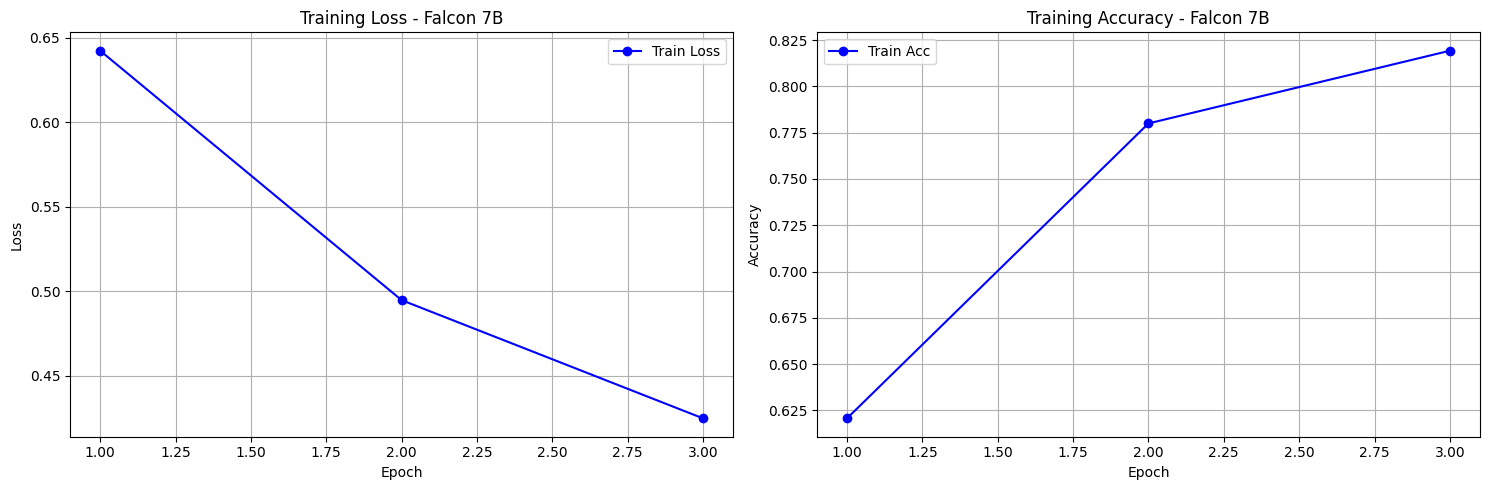

Train losses: [0.6424016668595405, 0.49479974528061754, 0.424844416157331]
Train accuracies: [0.6207561728395061, 0.7799639917695473, 0.8192193930041153]
Best val accuracy: 0.8482510288065843


In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
ax1.plot(range(1, EPOCHS + 1), train_losses, 'b-', label='Train Loss', marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss - Falcon 7B')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(range(1, EPOCHS + 1), train_accuracies, 'b-', label='Train Acc', marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training Accuracy - Falcon 7B')
ax2.legend()
ax2.grid(True)

plt.tight_layout()

# Save plot
plot_file = f'{OUTPUT_PATH}/training_curves_falcon.png'
plt.savefig(plot_file, dpi=300, bbox_inches='tight')
print(f'Plot saved to {plot_file}')

plt.show()

print(f'Train losses: {train_losses}')
print(f'Train accuracies: {train_accuracies}')
print(f'Best val accuracy: {best_val_accuracy}')

In [22]:
print('Saving best model...')

# Save only the classifier weights — same as Llama
model_save_path = f'{MODEL_PATH}/falcon_sentence_scorer.pt'
torch.save({
    'classifier_state_dict': model.classifier.state_dict(),
    'best_val_accuracy': best_val_accuracy,
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_accuracies': train_accuracies,
    'val_accuracies': val_accuracies,
    'hyperparameters': {
        'epochs': EPOCHS,
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'model_name': 'Falcon-7B',
    }
}, model_save_path)

print(f' Model saved to {model_save_path}')
print(f'File size: {os.path.getsize(model_save_path) / 1024 / 1024:.2f} MB')

Saving best model...
 Model saved to /content/drive/MyDrive/SinBrief_Implementation/Models/falcon_sentence_scorer.pt
File size: 4.57 MB


In [24]:
# Create training log
training_log = {
    'model': 'Falcon-7B',
    'approach': 'Base embeddings + custom classifier (same as mBERT and Llama)',
    'best_val_accuracy': float(best_val_accuracy),
    'final_train_accuracy': float(train_accuracies[-1]),
    'final_val_accuracy': float(val_accuracies[-1]),
    'epochs': EPOCHS,
    'train_losses': [float(x) for x in train_losses],
    'val_losses': [float(x) for x in val_losses],
    'train_accuracies': [float(x) for x in train_accuracies],
    'val_accuracies': [float(x) for x in val_accuracies],
    'total_training_samples': len(train_texts),
    'total_validation_samples': len(val_texts),
    'hyperparameters': {
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS,
        'warmup_steps': WARMUP_STEPS,
        'quantization': '4-bit',
        'base_model': 'AutoModel (no generation head)'
    }
}

log_file = f'{OUTPUT_PATH}/training_log_falcon.json'
with open(log_file, 'w', encoding='utf-8') as f:
    json.dump(training_log, f, indent=2, ensure_ascii=False)

print(f' Training log saved to {log_file}')

 Training log saved to /content/drive/MyDrive/SinBrief_Implementation/Outputs/training_log_falcon.json
